In [5]:
%matplotlib inline

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
)

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

X_train = train.drop(columns=["RiskLevel"])
y_train = train["RiskLevel"]
X_test  = test.drop(columns=["RiskLevel"])
y_test  = test["RiskLevel"]

LABELS = ["low risk", "mid risk", "high risk"]
print(X_train.shape, y_train.value_counts().to_dict())

(360, 6) {'low risk': 186, 'high risk': 89, 'mid risk': 85}


## Logistic Regression
## Подбор гиперпараметров
Стратифицированный 5-fold CV, метрика отбора — f1_macro.

In [6]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=4000,
        random_state=42,
    )),
])

C_grid = np.logspace(-2, 2, 9)  # 0.01 … 100

param_grid = [{
    "clf__solver": ["saga"],
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    "clf__l1_ratio": [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "clf__class_weight": ["balanced", None],
}]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe, param_grid,
    scoring="f1_macro",
    cv=cv, n_jobs=-1, refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"grid search: {time.perf_counter() - t0:.1f} сек")
print("best:", search.best_params_)
print(f"CV f1_macro: {search.best_score_:.3f} ± {search.cv_results_['std_test_score'][search.best_index_]:.3f}")

grid search: 6.4 сек
best: {'clf__C': 0.03, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.5, 'clf__solver': 'saga'}
CV f1_macro: 0.601 ± 0.030


## Топ комбинаций по CV

In [7]:
res = pd.DataFrame(search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_clf__C,param_clf__class_weight,param_clf__l1_ratio,param_clf__solver,mean_test_score,std_test_score,mean_train_score,mean_fit_time
27,0.03,balanced,0.5,saga,0.601,0.030,0.621,0.008
28,0.03,balanced,0.6,saga,0.597,0.033,0.616,0.008
29,0.03,balanced,0.7,saga,0.596,0.034,0.604,0.007
1,0.01,balanced,0.1,saga,0.589,0.039,0.602,0.083
26,0.03,balanced,0.4,saga,0.585,0.029,0.621,0.007
30,0.03,balanced,0.8,saga,0.581,0.036,0.594,0.008
2,0.01,balanced,0.2,saga,0.580,0.047,0.592,0.079
25,0.03,balanced,0.3,saga,0.579,0.025,0.606,0.007
24,0.03,balanced,0.2,saga,0.576,0.028,0.607,0.007
23,0.03,balanced,0.1,saga,0.575,0.021,0.595,0.007


## OOF-оценка на train
Честное качество без теста. ± из сетки — разброс по фолдам.

In [8]:
oof = cross_val_predict(search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print(f"OOF accuracy : {accuracy_score(y_train, oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(
    LABELS,
    recall_score(y_train, oof, labels=LABELS, average=None).round(3),
)))
print("OOF precision :", dict(zip(
    LABELS,
    precision_score(y_train, oof, labels=LABELS, average=None).round(3),
)))
print()
print(classification_report(y_train, oof, labels=LABELS, digits=3))

OOF accuracy : 0.669
OOF f1_macro : 0.604
OOF recall    : {'low risk': np.float64(0.849), 'mid risk': np.float64(0.318), 'high risk': np.float64(0.629)}
OOF precision : {'low risk': np.float64(0.756), 'mid risk': np.float64(0.375), 'high risk': np.float64(0.709)}

              precision    recall  f1-score   support

    low risk      0.756     0.849     0.800       186
    mid risk      0.375     0.318     0.344        85
   high risk      0.709     0.629     0.667        89

    accuracy                          0.669       360
   macro avg      0.613     0.599     0.604       360
weighted avg      0.654     0.669     0.659       360



## Матрица ошибок OOF
Слева штуки, справа доля по истинному классу (recall).

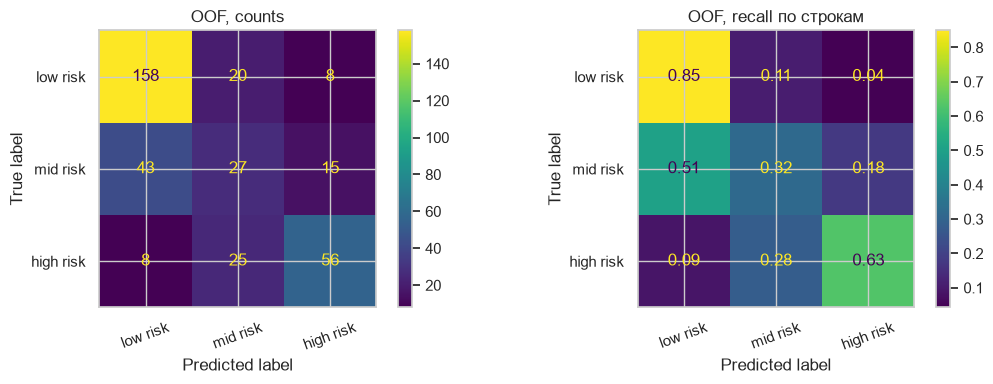

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("OOF, counts")

ConfusionMatrixDisplay.from_predictions(
    y_train, oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

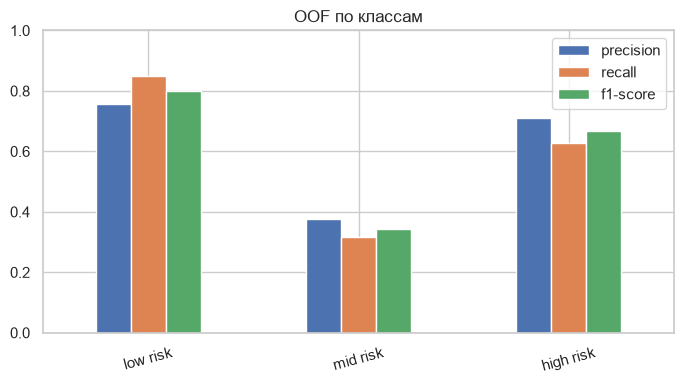

,precision,recall,f1-score
low risk,0.756,0.849,0.800
mid risk,0.375,0.318,0.344
high risk,0.709,0.629,0.667


In [10]:
rep = classification_report(y_train, oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## SVM
## Подбор гиперпараметров

In [11]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(class_weight="balanced", random_state=42)),
])

svm_grid = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
        "clf__class_weight": ["balanced", None],
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 0.3, 1, 3, 10, 30, 100],
        "clf__gamma": ["scale", 0.01, 0.03, 0.1, 0.3, 1],
        "clf__class_weight": ["balanced", None],
    },
]

svm_search = GridSearchCV(
    svm_pipe, svm_grid,
    scoring="f1_macro",
    cv=cv, n_jobs=-1, refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
print(f"grid search: {time.perf_counter() - t0:.1f} сек")
print("best:", svm_search.best_params_)
print(f"CV f1_macro: {svm_search.best_score_:.3f} ± {svm_search.cv_results_['std_test_score'][svm_search.best_index_]:.3f}")

grid search: 1.4 сек
best: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.03, 'clf__kernel': 'rbf'}
CV f1_macro: 0.676 ± 0.017


## Топ комбинаций по CV

In [12]:
res = pd.DataFrame(svm_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_clf__C,param_clf__class_weight,param_clf__kernel,param_clf__gamma,mean_test_score,std_test_score,mean_train_score,mean_fit_time
92,100.0,balanced,rbf,0.03,0.676,0.017,0.740,0.013
69,10.0,balanced,rbf,0.1,0.658,0.016,0.751,0.011
98,100.0,None,rbf,0.03,0.649,0.046,0.733,0.013
54,3.0,balanced,rbf,scale,0.645,0.029,0.749,0.010
75,10.0,None,rbf,0.1,0.637,0.042,0.744,0.010
57,3.0,balanced,rbf,0.1,0.633,0.040,0.716,0.011
91,100.0,balanced,rbf,0.01,0.631,0.033,0.682,0.011
80,30.0,balanced,rbf,0.03,0.631,0.037,0.714,0.012
60,3.0,None,rbf,scale,0.626,0.035,0.734,0.010
34,0.3,balanced,rbf,0.3,0.624,0.055,0.693,0.011


## OOF-оценка на train

In [13]:
svm_oof = cross_val_predict(svm_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print("best:", svm_search.best_params_)
print(f"CV f1_macro: {svm_search.best_score_:.3f} ± {svm_search.cv_results_['std_test_score'][svm_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, svm_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, svm_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, svm_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, svm_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, svm_oof, labels=LABELS, digits=3))

best: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.03, 'clf__kernel': 'rbf'}
CV f1_macro: 0.676 ± 0.017
OOF accuracy : 0.725
OOF f1_macro : 0.680
OOF recall    : {'low risk': np.float64(0.839), 'mid risk': np.float64(0.412), 'high risk': np.float64(0.787)}
OOF precision : {'low risk': np.float64(0.78), 'mid risk': np.float64(0.507), 'high risk': np.float64(0.769)}

              precision    recall  f1-score   support

    low risk      0.780     0.839     0.808       186
    mid risk      0.507     0.412     0.455        85
   high risk      0.769     0.787     0.778        89

    accuracy                          0.725       360
   macro avg      0.685     0.679     0.680       360
weighted avg      0.713     0.725     0.717       360



## Матрица ошибок OOF

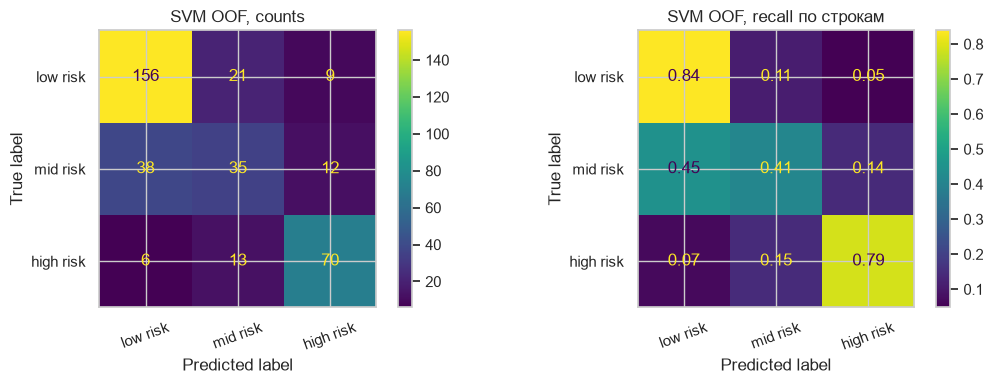

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, svm_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("SVM OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, svm_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("SVM OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

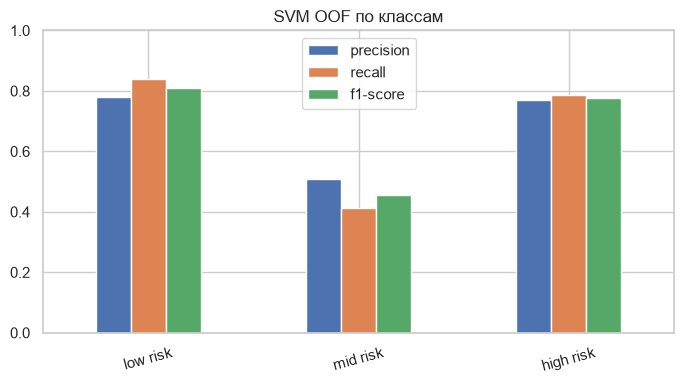

,precision,recall,f1-score
low risk,0.780,0.839,0.808
mid risk,0.507,0.412,0.455
high risk,0.769,0.787,0.778


In [15]:
rep = classification_report(y_train, svm_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("SVM OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## Decision Tree
## Подбор гиперпараметров
Глубину и лист режем специально, иначе дерево зазубривает train.

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42, max_features=None)

tree_space = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, 12],
    "min_samples_leaf": [1, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 8, 16],
    "class_weight": ["balanced", None],
    "ccp_alpha": [0.0, 0.001, 0.003, 0.01, 0.02],
}

tree_search = RandomizedSearchCV(
    tree,
    tree_space,
    n_iter=500,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
tree_search.fit(X_train, y_train)
print(f"random search: {time.perf_counter() - t0:.1f} сек")
print("best:", tree_search.best_params_)
print(f"CV f1_macro: {tree_search.best_score_:.3f} ± {tree_search.cv_results_['std_test_score'][tree_search.best_index_]:.3f}")

random search: 11.3 сек
best: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.02}
CV f1_macro: 0.671 ± 0.023


## Топ комбинаций по CV

In [17]:
res = pd.DataFrame(tree_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_criterion,param_class_weight,param_ccp_alpha,mean_test_score,std_test_score,mean_train_score,mean_fit_time
471,16,4,5,entropy,balanced,0.020,0.671,0.023,0.709,0.005
46,2,4,5,entropy,balanced,0.020,0.671,0.023,0.709,0.003
369,2,1,5,entropy,balanced,0.020,0.670,0.023,0.714,0.003
470,16,2,4,entropy,balanced,0.020,0.664,0.027,0.702,0.005
468,2,6,10,entropy,balanced,0.020,0.664,0.031,0.706,0.004
166,2,4,6,entropy,balanced,0.020,0.664,0.031,0.706,0.004
4,8,4,8,entropy,balanced,0.020,0.664,0.031,0.709,0.003
376,8,1,6,entropy,balanced,0.020,0.662,0.031,0.711,0.004
191,2,2,8,entropy,balanced,0.020,0.662,0.031,0.711,0.003
242,16,2,4,gini,balanced,0.001,0.662,0.029,0.709,0.003


## OOF-оценка на train

In [18]:
tree_oof = cross_val_predict(tree_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print("best:", tree_search.best_params_)
print(f"CV f1_macro: {tree_search.best_score_:.3f} ± {tree_search.cv_results_['std_test_score'][tree_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, tree_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, tree_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, tree_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, tree_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, tree_oof, labels=LABELS, digits=3))

best: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.02}
CV f1_macro: 0.671 ± 0.023
OOF accuracy : 0.733
OOF f1_macro : 0.672
OOF recall    : {'low risk': np.float64(0.882), 'mid risk': np.float64(0.353), 'high risk': np.float64(0.787)}
OOF precision : {'low risk': np.float64(0.792), 'mid risk': np.float64(0.508), 'high risk': np.float64(0.745)}

              precision    recall  f1-score   support

    low risk      0.792     0.882     0.835       186
    mid risk      0.508     0.353     0.417        85
   high risk      0.745     0.787     0.765        89

    accuracy                          0.733       360
   macro avg      0.682     0.674     0.672       360
weighted avg      0.713     0.733     0.719       360



## Матрица ошибок OOF

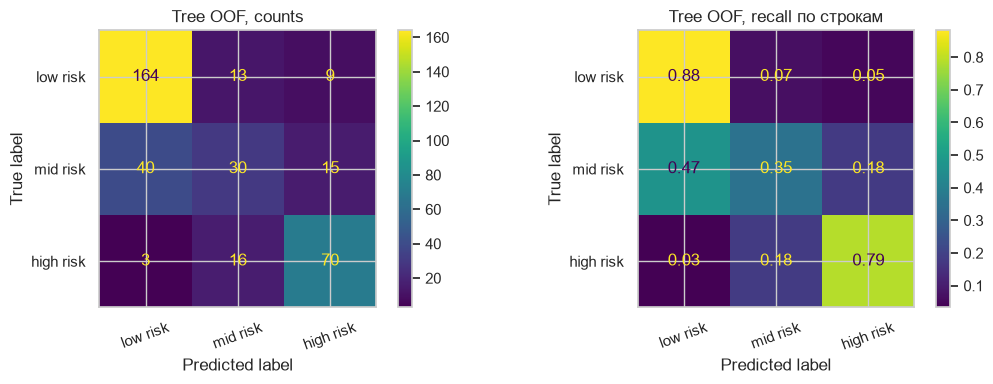

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, tree_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("Tree OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, tree_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("Tree OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

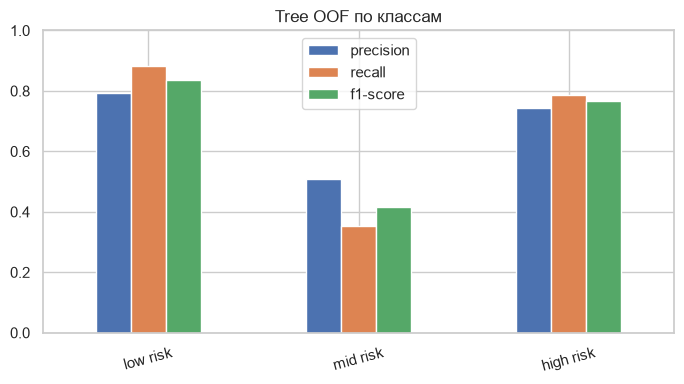

,precision,recall,f1-score
low risk,0.792,0.882,0.835
mid risk,0.508,0.353,0.417
high risk,0.745,0.787,0.765


In [20]:
rep = classification_report(y_train, tree_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("Tree OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## Random Forest
## Подбор гиперпараметров
Random search, 500 итераций. Скейлер не нужен.

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

rf = RandomForestClassifier(
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

rf_space = {
    "n_estimators": randint(100, 501),
    "max_depth": randint(3, 16),
    "min_samples_split": randint(2, 31),
    "min_samples_leaf": randint(1, 16),
    "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7, 1.0],
    "max_samples": uniform(0.5, 0.5),   # доля строк на одно дерево: 0.5…1.0
    "class_weight": ["balanced", "balanced_subsample", None],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0.0, 0.001, 0.003, 0.01],
}

rf_search = RandomizedSearchCV(
    rf, rf_space,
    n_iter=500,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
print(f"random search: {time.perf_counter() - t0:.1f} сек")
print("best:", rf_search.best_params_)
print(f"CV f1_macro: {rf_search.best_score_:.3f} ± {rf_search.cv_results_['std_test_score'][rf_search.best_index_]:.3f}")

random search: 206.4 сек
best: {'ccp_alpha': 0.0, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_depth': 5, 'max_features': 0.5, 'max_samples': np.float64(0.6889937950611272), 'min_samples_leaf': 7, 'min_samples_split': 28, 'n_estimators': 301}
CV f1_macro: 0.675 ± 0.015


## Топ комбинаций по CV

In [22]:
res = pd.DataFrame(rf_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_ccp_alpha,param_class_weight,param_criterion,param_max_depth,param_max_features,param_max_samples,param_min_samples_leaf,param_min_samples_split,param_n_estimators,mean_test_score,std_test_score,mean_train_score,mean_fit_time
78,0.000,balanced_subsample,entropy,5,0.5,0.689,7,28,301,0.675,0.015,0.683,1.259
390,0.001,balanced_subsample,entropy,6,0.5,0.773,3,20,129,0.674,0.022,0.707,0.543
154,0.010,balanced_subsample,entropy,5,0.7,0.763,1,24,154,0.672,0.019,0.691,0.765
472,0.010,balanced,gini,4,0.7,0.885,9,29,112,0.672,0.018,0.679,0.366
378,0.010,balanced_subsample,entropy,13,1.0,0.565,5,26,230,0.672,0.014,0.686,1.002
370,0.000,balanced_subsample,entropy,5,0.7,0.686,7,26,478,0.671,0.022,0.688,1.809
98,0.000,balanced,entropy,4,None,0.606,6,29,325,0.671,0.020,0.674,0.939
87,0.003,balanced_subsample,gini,3,sqrt,0.655,4,14,319,0.671,0.027,0.702,1.248
187,0.000,balanced_subsample,entropy,5,None,0.999,4,30,417,0.671,0.020,0.683,1.859
130,0.000,balanced_subsample,gini,4,1.0,0.857,3,30,452,0.671,0.020,0.679,1.881


## OOF-оценка на train

In [23]:
rf_oof = cross_val_predict(rf_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print("best:", rf_search.best_params_)
print(f"CV f1_macro: {rf_search.best_score_:.3f} ± {rf_search.cv_results_['std_test_score'][rf_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, rf_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, rf_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, rf_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, rf_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, rf_oof, labels=LABELS, digits=3))

best: {'ccp_alpha': 0.0, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_depth': 5, 'max_features': 0.5, 'max_samples': np.float64(0.6889937950611272), 'min_samples_leaf': 7, 'min_samples_split': 28, 'n_estimators': 301}
CV f1_macro: 0.675 ± 0.015
OOF accuracy : 0.742
OOF f1_macro : 0.676
OOF recall    : {'low risk': np.float64(0.876), 'mid risk': np.float64(0.318), 'high risk': np.float64(0.865)}
OOF precision : {'low risk': np.float64(0.799), 'mid risk': np.float64(0.509), 'high risk': np.float64(0.748)}

              precision    recall  f1-score   support

    low risk      0.799     0.876     0.836       186
    mid risk      0.509     0.318     0.391        85
   high risk      0.748     0.865     0.802        89

    accuracy                          0.742       360
   macro avg      0.685     0.686     0.676       360
weighted avg      0.718     0.742     0.723       360



## Матрица ошибок OOF

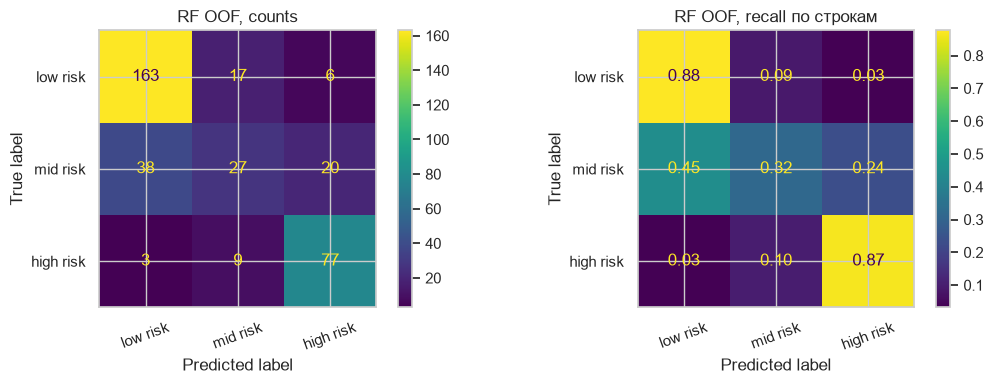

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, rf_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("RF OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, rf_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("RF OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

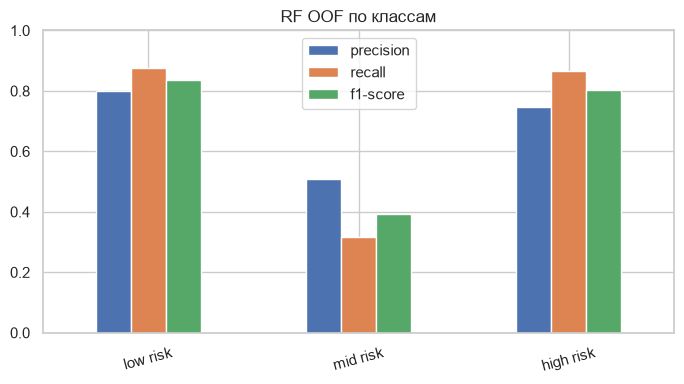

,precision,recall,f1-score
low risk,0.799,0.876,0.836
mid risk,0.509,0.318,0.391
high risk,0.748,0.865,0.802


In [25]:
rep = classification_report(y_train, rf_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("RF OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## XGBoost
## Подбор гиперпараметров
Random search, 300 итераций. Глубину держим небольшой — выборка маленькая.

In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint, uniform, loguniform

label_to_id = {c: i for i, c in enumerate(LABELS)}
id_to_label = {i: c for c, i in label_to_id.items()}
y_tr_enc = y_train.map(label_to_id)
sw = compute_sample_weight("balanced", y_train)

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

xgb_space = {
    "n_estimators": randint(80, 401),
    "max_depth": randint(2, 7),
    "learning_rate": loguniform(0.01, 0.3),
    "min_child_weight": randint(1, 13),
    "gamma": uniform(0.0, 2.0),
    "subsample": uniform(0.6, 0.4),          # 0.6…1.0
    "colsample_bytree": uniform(0.5, 0.5),   # 0.5…1.0
    "reg_lambda": loguniform(0.1, 10.0),
    "reg_alpha": loguniform(1e-3, 1.0),
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_space,
    n_iter=500,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
xgb_search.fit(X_train, y_tr_enc, sample_weight=sw)
print(f"random search: {time.perf_counter() - t0:.1f} сек")
print("best:", xgb_search.best_params_)
print(f"CV f1_macro: {xgb_search.best_score_:.3f} ± {xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]:.3f}")

random search: 77.7 сек
best: {'colsample_bytree': np.float64(0.5597971229691509), 'gamma': np.float64(1.42648957444599), 'learning_rate': np.float64(0.13297554090738672), 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 334, 'reg_alpha': np.float64(0.005864148617634941), 'reg_lambda': np.float64(0.12046674587990323), 'subsample': np.float64(0.8842651558743149)}
CV f1_macro: 0.674 ± 0.030


## Топ комбинаций по CV

In [33]:
res = pd.DataFrame(xgb_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_colsample_bytree,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample,mean_test_score,std_test_score,mean_train_score,mean_fit_time
11,0.560,1.426,0.133,3,7,334,0.006,0.120,0.884,0.674,0.030,0.725,0.612
97,0.509,1.744,0.238,5,4,212,0.585,2.597,0.661,0.672,0.039,0.708,0.396
345,0.696,1.509,0.227,2,7,170,0.007,1.754,0.997,0.672,0.043,0.690,0.320
243,0.876,1.314,0.259,5,10,299,0.007,0.356,0.915,0.670,0.040,0.734,0.500
136,0.732,1.246,0.127,2,9,147,0.055,0.152,0.951,0.669,0.037,0.715,0.252
433,0.834,1.554,0.188,6,1,111,0.466,0.553,0.678,0.669,0.041,0.737,0.201
110,0.543,1.266,0.122,6,3,191,0.004,1.466,0.769,0.668,0.033,0.742,0.319
171,0.803,0.713,0.061,2,1,199,0.261,1.482,0.947,0.668,0.046,0.726,0.329
62,0.538,1.881,0.041,6,9,89,0.628,5.397,0.618,0.667,0.023,0.669,0.183
83,0.699,1.939,0.190,2,8,141,0.614,1.299,0.829,0.667,0.035,0.683,0.237


## OOF-оценка на train

In [34]:
xgb_oof_id = cross_val_predict(
    xgb_search.best_estimator_, X_train, y_tr_enc,
    cv=cv, n_jobs=-1, params={"sample_weight": sw},
)
xgb_oof = pd.Series(xgb_oof_id).map(id_to_label)

print("best:", xgb_search.best_params_)
print(f"CV f1_macro: {xgb_search.best_score_:.3f} ± {xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, xgb_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, xgb_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, xgb_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, xgb_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, xgb_oof, labels=LABELS, digits=3))

best: {'colsample_bytree': np.float64(0.5597971229691509), 'gamma': np.float64(1.42648957444599), 'learning_rate': np.float64(0.13297554090738672), 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 334, 'reg_alpha': np.float64(0.005864148617634941), 'reg_lambda': np.float64(0.12046674587990323), 'subsample': np.float64(0.8842651558743149)}
CV f1_macro: 0.674 ± 0.030
OOF accuracy : 0.736
OOF f1_macro : 0.690
OOF recall    : {'low risk': np.float64(0.844), 'mid risk': np.float64(0.4), 'high risk': np.float64(0.831)}
OOF precision : {'low risk': np.float64(0.785), 'mid risk': np.float64(0.531), 'high risk': np.float64(0.771)}

              precision    recall  f1-score   support

    low risk      0.785     0.844     0.813       186
    mid risk      0.531     0.400     0.456        85
   high risk      0.771     0.831     0.800        89

    accuracy                          0.736       360
   macro avg      0.696     0.692     0.690       360
weighted avg      0.722     0.736    

In [35]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

# fallback без params:
xgb_oof_id = cross_val_predict(xgb_search.best_estimator_, X_train, y_tr_enc, cv=cv, n_jobs=-1)

## Матрица ошибок OOF

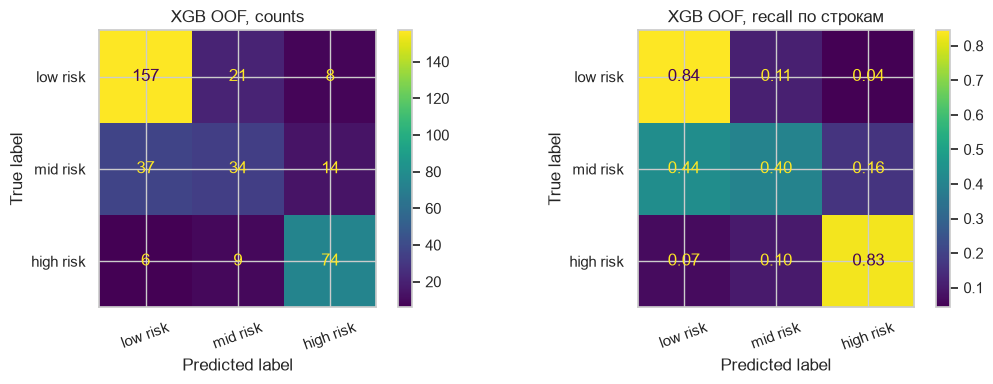

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, xgb_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("XGB OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, xgb_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("XGB OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

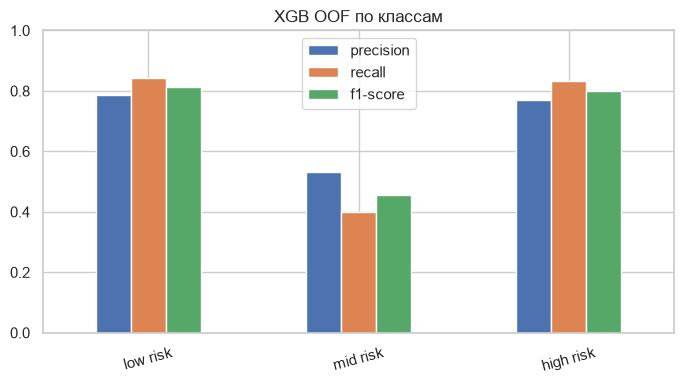

,precision,recall,f1-score
low risk,0.785,0.844,0.813
mid risk,0.531,0.400,0.456
high risk,0.771,0.831,0.800


In [37]:
rep = classification_report(y_train, xgb_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("XGB OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## MLP
## Подбор гиперпараметров
Маленькая сеть + early stopping. Скейлер обязателен.

In [43]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import loguniform

w = compute_sample_weight("balanced", y_train)
# mid ещё чуть усиливаем руками
w = w * y_train.map({"low risk": 1.0, "mid risk": 1.8, "high risk": 1.3}).to_numpy()

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        solver="adam",
        early_stopping=False,   # на такой выборке val-split врёт
        max_iter=1500,
        random_state=42,
    )),
])

mlp_space = {
    "clf__hidden_layer_sizes": [(8,), (16,), (16, 8), (12, 8)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": loguniform(1e-3, 3e-1),
    "clf__learning_rate_init": loguniform(5e-4, 1e-2),
    "clf__batch_size": [16, 32],
}

mlp_search = RandomizedSearchCV(
    mlp_pipe, mlp_space,
    n_iter=40,
    scoring="f1_macro",
    cv=cv, n_jobs=-1, random_state=42,
    refit=True, return_train_score=True,
)

mlp_search.fit(X_train, y_train, clf__sample_weight=w)
print("best:", mlp_search.best_params_)
print(f"CV f1_macro: {mlp_search.best_score_:.3f} ± {mlp_search.cv_results_['std_test_score'][mlp_search.best_index_]:.3f}")

best: {'clf__activation': 'relu', 'clf__alpha': np.float64(0.0026880990539303916), 'clf__batch_size': 16, 'clf__hidden_layer_sizes': (12, 8), 'clf__learning_rate_init': np.float64(0.0008631069642003106)}
CV f1_macro: 0.605 ± 0.043


## Топ комбинаций по CV

In [44]:
res = pd.DataFrame(mlp_search.cv_results_)
cols = [c for c in res.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time"
]
display(res[cols].sort_values("mean_test_score", ascending=False).head(12).round(3))

,param_clf__activation,param_clf__alpha,param_clf__batch_size,param_clf__hidden_layer_sizes,param_clf__learning_rate_init,mean_test_score,std_test_score,mean_train_score,mean_fit_time
12,relu,0.003,16,"(12, 8)",0.001,0.605,0.043,0.707,2.786
34,relu,0.006,16,"(12, 8)",0.001,0.604,0.035,0.709,1.630
0,relu,0.094,16,"(16, 8)",0.005,0.574,0.014,0.736,1.347
10,tanh,0.009,32,"(8,)",0.001,0.571,0.040,0.603,0.925
4,tanh,0.287,16,"(12, 8)",0.003,0.571,0.047,0.621,1.093
5,relu,0.012,16,"(16, 8)",0.003,0.570,0.053,0.778,2.481
16,tanh,0.026,32,"(8,)",0.009,0.569,0.057,0.690,0.885
25,tanh,0.158,16,"(16, 8)",0.001,0.567,0.030,0.613,1.441
29,relu,0.006,32,"(12, 8)",0.008,0.566,0.042,0.755,0.759
32,tanh,0.035,32,"(8,)",0.001,0.566,0.037,0.593,0.784


## OOF-оценка на train

In [45]:
mlp_oof = cross_val_predict(mlp_search.best_estimator_, X_train, y_train, cv=cv, n_jobs=-1)

print("best:", mlp_search.best_params_)
print(f"CV f1_macro: {mlp_search.best_score_:.3f} ± {mlp_search.cv_results_['std_test_score'][mlp_search.best_index_]:.3f}")
print(f"OOF accuracy : {accuracy_score(y_train, mlp_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, mlp_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, mlp_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, mlp_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, mlp_oof, labels=LABELS, digits=3))

best: {'clf__activation': 'relu', 'clf__alpha': np.float64(0.0026880990539303916), 'clf__batch_size': 16, 'clf__hidden_layer_sizes': (12, 8), 'clf__learning_rate_init': np.float64(0.0008631069642003106)}
CV f1_macro: 0.605 ± 0.043
OOF accuracy : 0.694
OOF f1_macro : 0.621
OOF recall    : {'low risk': np.float64(0.876), 'mid risk': np.float64(0.282), 'high risk': np.float64(0.708)}
OOF precision : {'low risk': np.float64(0.744), 'mid risk': np.float64(0.471), 'high risk': np.float64(0.7)}

              precision    recall  f1-score   support

    low risk      0.744     0.876     0.805       186
    mid risk      0.471     0.282     0.353        85
   high risk      0.700     0.708     0.704        89

    accuracy                          0.694       360
   macro avg      0.638     0.622     0.621       360
weighted avg      0.669     0.694     0.673       360



## Матрица ошибок OOF

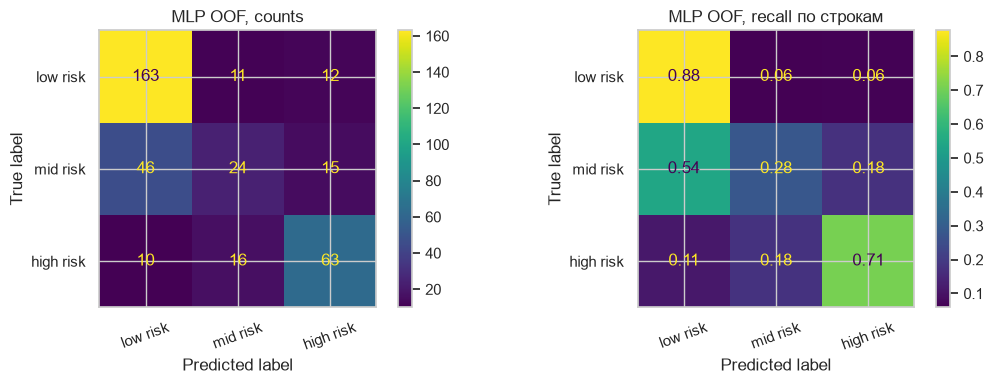

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, mlp_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("MLP OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, mlp_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("MLP OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

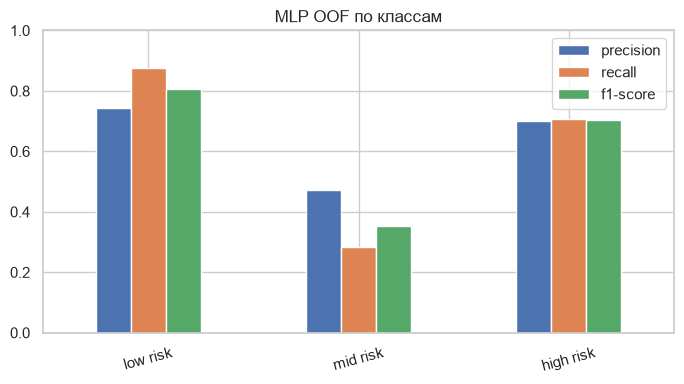

,precision,recall,f1-score
low risk,0.744,0.876,0.805
mid risk,0.471,0.282,0.353
high risk,0.700,0.708,0.704


In [47]:
rep = classification_report(y_train, mlp_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("MLP OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))

## Stacking
Базы — лучшие SVM, RF, XGB из поиска.

In [48]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=100,
        gamma=0.03,
        class_weight="balanced",
        probability=True,
        random_state=42,
    )),
])

rf_base = RandomForestClassifier(
    n_estimators=301,
    max_depth=5,
    max_features=0.5,
    max_samples=0.6889937950611272,
    min_samples_leaf=7,
    min_samples_split=28,
    criterion="entropy",
    class_weight="balanced_subsample",
    ccp_alpha=0.0,
    bootstrap=True,
    random_state=42,
    n_jobs=1,
)

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    tree_method="hist",
    eval_metric="mlogloss",
    n_estimators=334,
    max_depth=3,
    learning_rate=0.13297554090738672,
    min_child_weight=7,
    gamma=1.42648957444599,
    subsample=0.8842651558743149,
    colsample_bytree=0.5597971229691509,
    reg_alpha=0.005864148617634941,
    reg_lambda=0.12046674587990323,
    random_state=42,
    n_jobs=1,
)

stack = StackingClassifier(
    estimators=[("svm", svm_base), ("rf", rf_base), ("xgb", xgb_base)],
    final_estimator=LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=42
    ),
    cv=cv,
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1,
)

t0 = time.perf_counter()
stack.fit(X_train, y_train)
print(f"fit stack: {time.perf_counter() - t0:.1f} сек")

fit stack: 8.4 сек


c:\Users\user\miniconda3\envs\main\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## OOF-оценка стека

In [49]:
stack_oof = cross_val_predict(stack, X_train, y_train, cv=cv, n_jobs=-1)

print(f"OOF accuracy : {accuracy_score(y_train, stack_oof):.3f}")
print(f"OOF f1_macro : {f1_score(y_train, stack_oof, average='macro'):.3f}")
print("OOF recall    :", dict(zip(LABELS, recall_score(y_train, stack_oof, labels=LABELS, average=None).round(3))))
print("OOF precision :", dict(zip(LABELS, precision_score(y_train, stack_oof, labels=LABELS, average=None).round(3))))
print()
print(classification_report(y_train, stack_oof, labels=LABELS, digits=3))

OOF accuracy : 0.725
OOF f1_macro : 0.666
OOF recall    : {'low risk': np.float64(0.855), 'mid risk': np.float64(0.341), 'high risk': np.float64(0.82)}
OOF precision : {'low risk': np.float64(0.787), 'mid risk': np.float64(0.492), 'high risk': np.float64(0.737)}

              precision    recall  f1-score   support

    low risk      0.787     0.855     0.820       186
    mid risk      0.492     0.341     0.403        85
   high risk      0.737     0.820     0.777        89

    accuracy                          0.725       360
   macro avg      0.672     0.672     0.666       360
weighted avg      0.705     0.725     0.711       360



## Матрица ошибок OOF

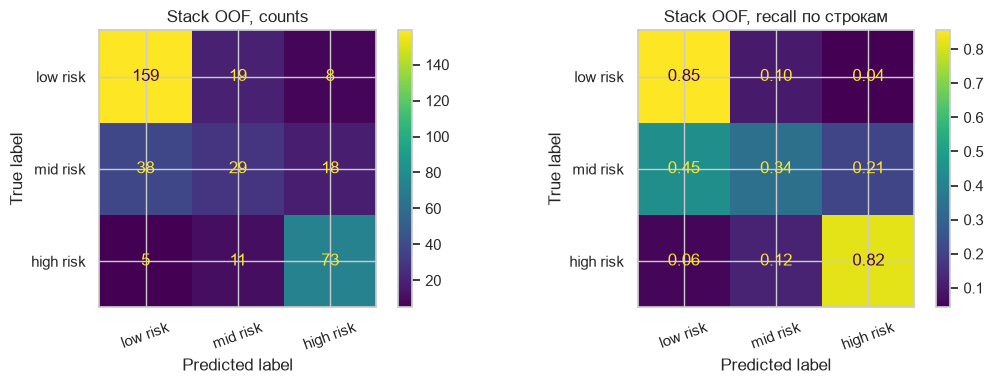

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, stack_oof, labels=LABELS, ax=axes[0], xticks_rotation=20
)
axes[0].set_title("Stack OOF, counts")
ConfusionMatrixDisplay.from_predictions(
    y_train, stack_oof, labels=LABELS, normalize="true",
    values_format=".2f", ax=axes[1], xticks_rotation=20
)
axes[1].set_title("Stack OOF, recall по строкам")
plt.tight_layout()
plt.show()

## Precision / recall / F1 по классам (OOF)

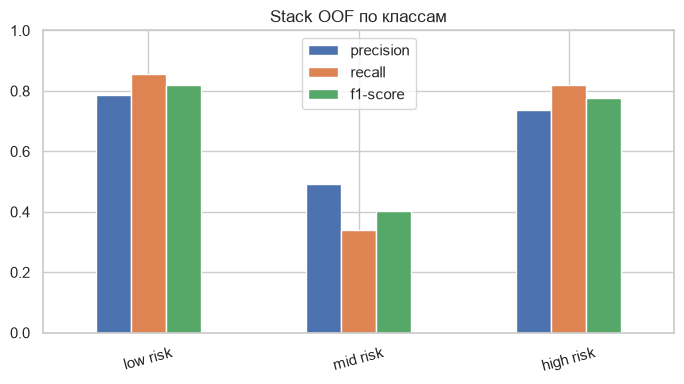

,precision,recall,f1-score
low risk,0.787,0.855,0.820
mid risk,0.492,0.341,0.403
high risk,0.737,0.820,0.777


In [51]:
rep = classification_report(y_train, stack_oof, labels=LABELS, output_dict=True)
per = pd.DataFrame(rep).T.loc[LABELS, ["precision", "recall", "f1-score"]]
per.plot(kind="bar", ylim=(0, 1), figsize=(7, 4))
plt.xticks(rotation=15)
plt.title("Stack OOF по классам")
plt.tight_layout()
plt.show()
display(per.round(3))